In [4]:
import pandas as pd

df = pd.read_csv('C:/Users/Stepheny/Desktop/Projects/Customer_Churn/data/churn.csv')

print(df.shape)
print(df.head())
print(df.columns)
df.info()


(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [5]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isna().sum())

11


In [6]:

df[df['tenure'] == 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [7]:
# Drop ID (not useful for prediction)
df = df.drop(columns=['customerID'])



# When tenure = 0, total charges should equal monthly charges
df.loc[df['tenure'] == 0, 'TotalCharges'] = df['MonthlyCharges']

# # Fill remaining missing
# df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

# Check
print(df.isnull().sum())


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
(df['TotalCharges']).isna().sum()

0

In [13]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())



gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']


In [14]:
df['SeniorCitizen'].unique()

array([0, 1], dtype=int64)

In [ ]:
# Filter rows with the specific condition
df_filtered = df[(df['PhoneService'] == 'No') & (df['MultipleLines'] != 'No phone service')]


df_filtered


In [ ]:
MultipleLines already contains all the information in PhoneService

If MultipleLines == "No phone service" → PhoneService is No

If MultipleLines != "No phone service" → PhoneService is Yes

So mathematically:

PhoneService is 100% determined by MultipleLines

In [17]:
df = df.drop(columns=['PhoneService'])


In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.798992
std,0.368612,24.559481,30.090047,2266.730170
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


##  Exploratory Data Analysis (EDA)

In [19]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("\nNumerical features:", numerical_features)
print("Categorical features:", categorical_features)



Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [15]:
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print("\nChurn proportion:")
print(df['Churn'].value_counts(normalize=True))



Churn distribution:
No     5174
Yes    1869
Name: Churn, dtype: int64

Churn proportion:
No     0.73463
Yes    0.26537
Name: Churn, dtype: float64


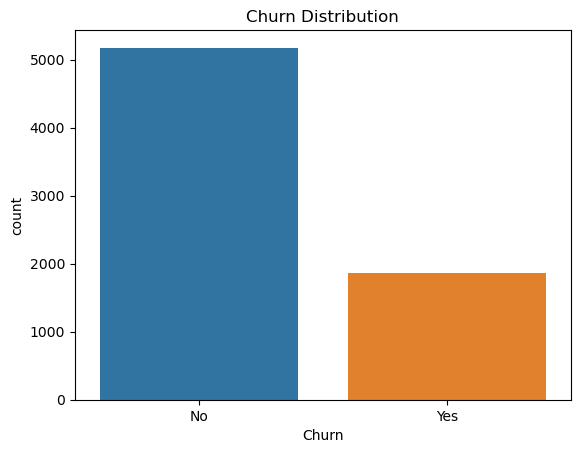

Churn rate: 26.54%


In [20]:

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

churn_rate = df['Churn'].value_counts(normalize=True).get('Yes',0)
print(f"Churn rate: {churn_rate:.2%}")

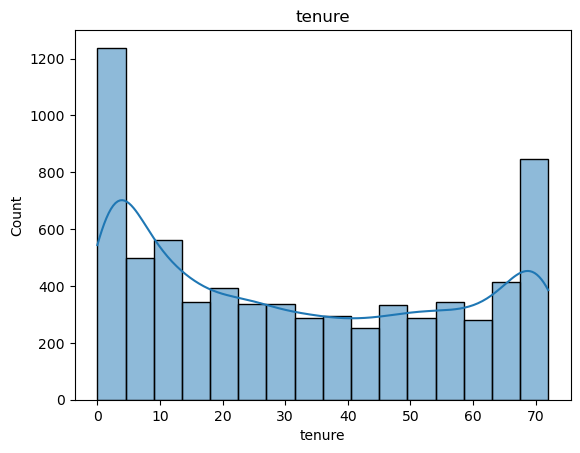

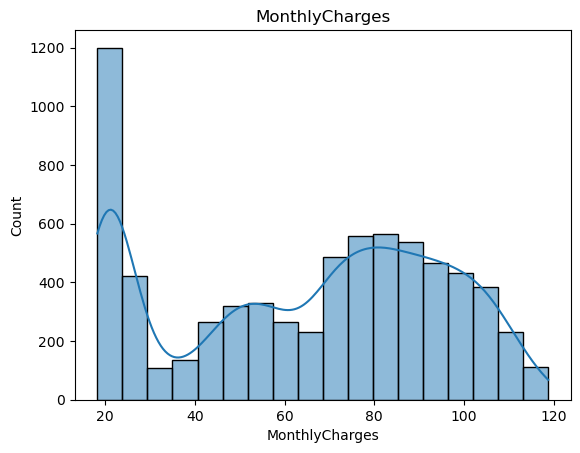

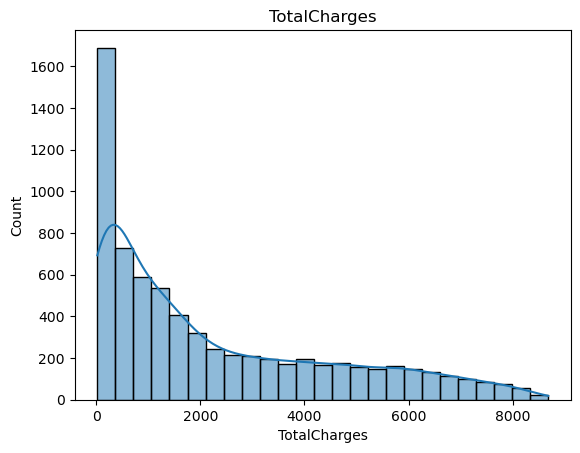

In [23]:
# Numerical distributions
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()




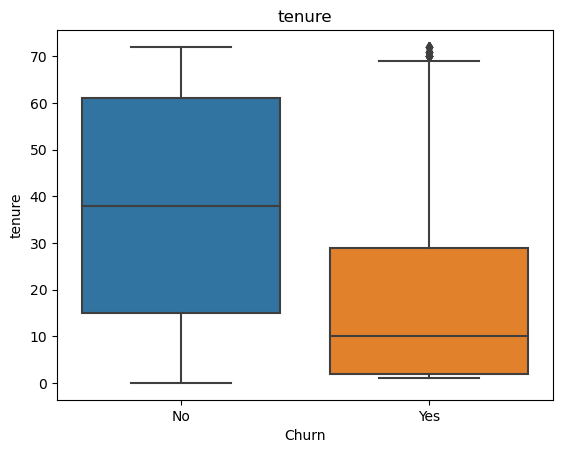

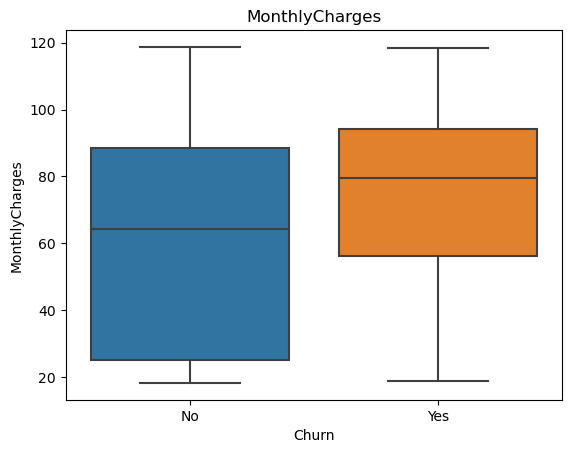

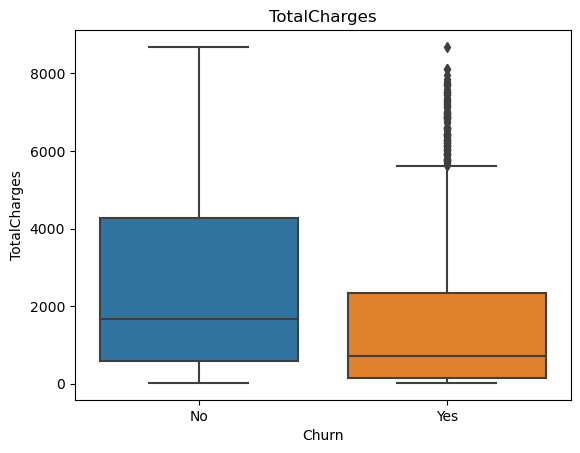

In [22]:
# Boxplots vs churn
for col in num_cols:
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(col)
    plt.show()

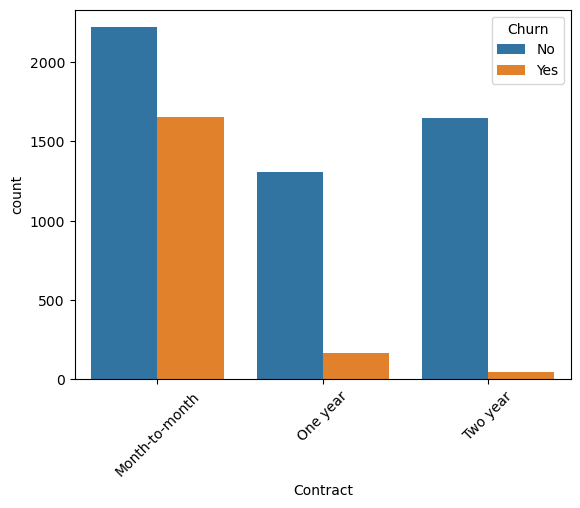

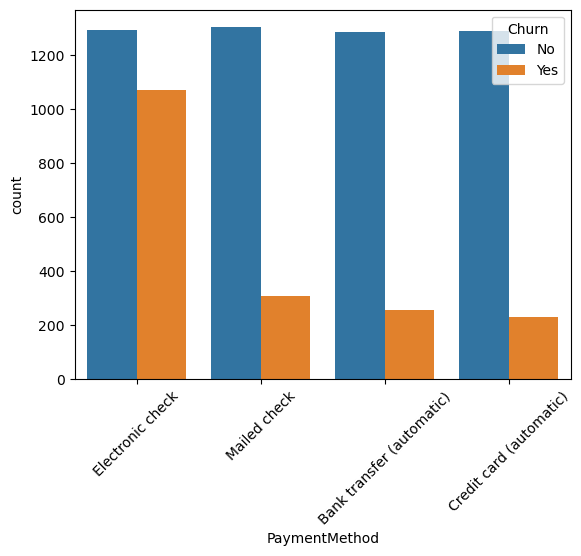

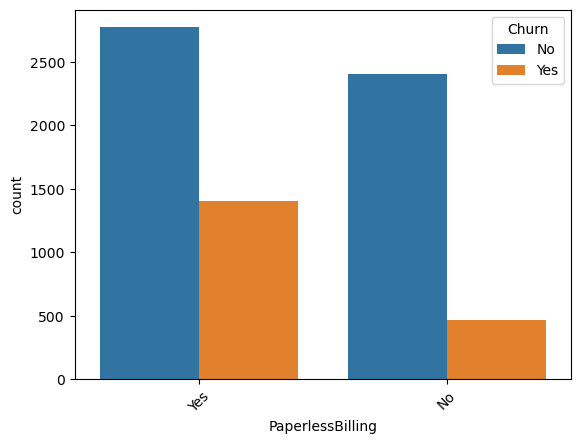

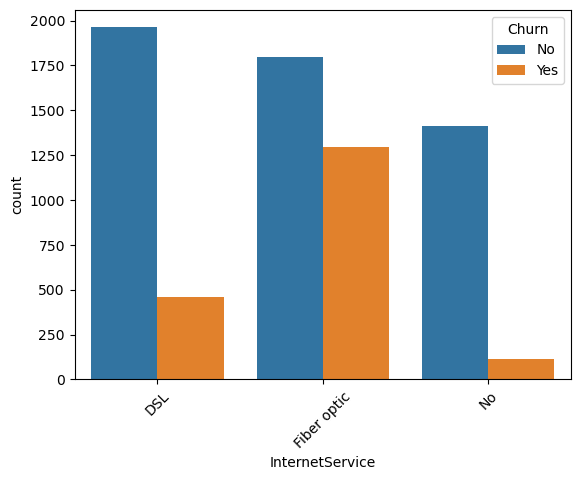

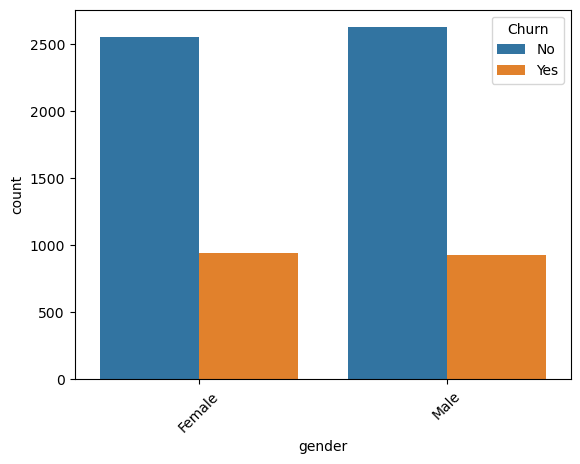

In [25]:
# Categorical vs churn
cat_cols = ['Contract','PaymentMethod','PaperlessBilling','InternetService','gender']

for col in cat_cols:
    sns.countplot(x=col, hue='Churn', data=df)
    plt.xticks(rotation=45)
    plt.show()

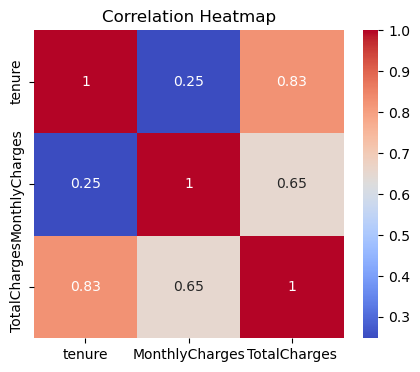

In [26]:
# --- 7. Bivariate correlations (numerical features) ---
corr = df[num_cols].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

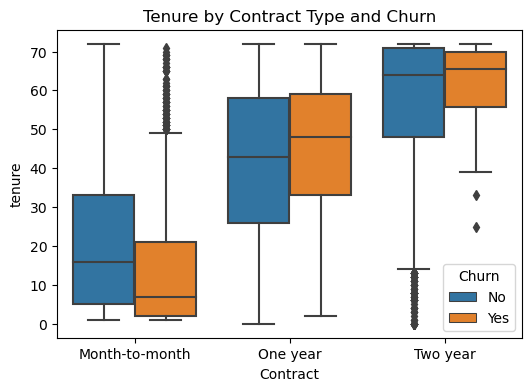

In [27]:
# --- 8. Churn by contract type and tenure ---
plt.figure(figsize=(6,4))
sns.boxplot(x='Contract', y='tenure', hue='Churn', data=df)
plt.title('Tenure by Contract Type and Churn')
plt.show()



In [28]:
# Insights
# Key Insights:
# 1. Month-to-month contracts have higher churn.
# 2. Short-tenure customers (<12 months) are most at risk.
# 3. High MonthlyCharges without service bundling correlates with churn.
# 4. Missing TotalCharges correspond to new customers — not random data issues.
# Customer ID removed as it is not required for modelling
# No missing values in the dataset
# Missing values in the TotalCharges column were replaced with MonthlyCharges
# Class imbalance identified in the target

SyntaxError: invalid syntax (1835913352.py, line 2)

In [ ]:
# Contract type is highly predictive

# Month-to-month customers have higher churn (~42% churn), whereas 1- or 2-year contracts are more stable.

# Tenure is inversely correlated with churn

# Customers with short tenure (<12 months) are most likely to leave.

# Long-term customers are far less likely to churn.

# Monthly charges impact churn

# High-paying customers without bundled services are more likely to churn.

# Service adoption matters

# Customers without internet or phone add-ons (security, backup, streaming) are slightly more likely to churn.

# Auto-payment and paperless billing

# Customers using automatic payments or paperless billing are slightly more loyal.

# These could be leveraged for retention strategies.

# TotalCharges reflects tenure

# For new customers, TotalCharges is low; for long-tenure, high.

# TotalCharges combined with tenure can help identify high-risk customers early.

# Feature engineering opportunities

# tenure_group → categorical bucket of tenure

# is_early_tenure → flag for <12 months

# is_month_to_month → contract risk flag

# has_internet → internet dependency

# is_high_value_customer → customers with high charges + long tenure

# Potential model considerations

# The dataset has mixed data types (numeric + categorical).

# One-hot encoding is required.

# Class imbalance suggests stratified train-test split or weighted models.

In [29]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [30]:
cleaned_df = pd.DataFrame(df)

# Export to CSV
cleaned_df.to_csv("cleaned_df.csv", index=False)